# MMM simplificado (Portfólio)

Este notebook mostra um *fluxo fim-a-fim* de MMM usando um dataset sintético semanal.

## Objetivos
- Preparar dados e entender padrões (EDA)
- Aplicar **adstock** e **saturação** nos canais
- Treinar um modelo linear interpretável (OLS)
- Fazer **decomposição** e recomendações de negócio


In [5]:
import os
os.getcwd()
os.listdir()

['.ipynb_checkpoints', '01_mmm_simplificado.ipynb']

In [ ]:
#!pip install -r requirements.txt

In [11]:
import sys
import warnings
sys.path.append("..")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.modelagem import TransformParams, build_design_matrix, train_linear_model, decompose_contributions

df = pd.read_csv("../data/raw/marketing_sales_weekly.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
df.head()


,date,sales,tv_spend,search_spend,social_spend,email_spend,price_index,promo
0,2022-01-03,304.729122,75.072122,61.034221,40.232992,16.381798,1.003047,0
1,2022-01-10,345.015224,85.063026,70.809455,59.424368,14.765001,0.998895,0
2,2022-01-17,397.435372,75.824602,61.666140,53.967073,16.232116,1.023964,1
3,2022-01-24,358.597766,91.561224,51.851887,42.790878,7.948552,1.029260,0
4,2022-01-31,374.161470,120.075266,40.699710,56.103185,4.304255,0.999190,0


## 1) EDA rápido
- Tendência e sazonalidade das vendas
- Gastos por canal


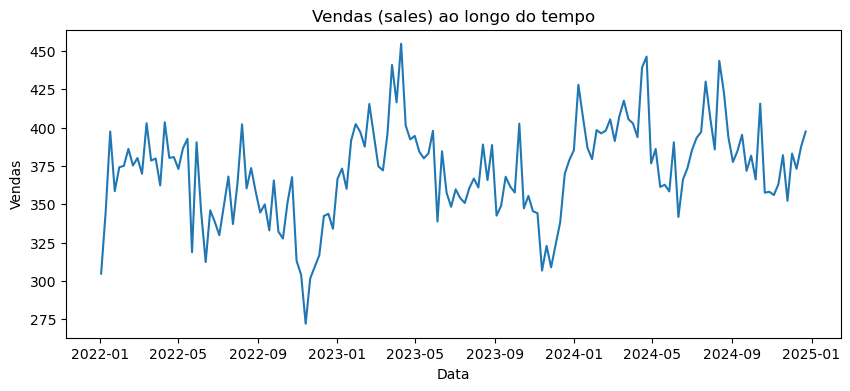

In [14]:
fig = plt.figure(figsize=(10,4))
plt.plot(df["date"], df["sales"])
plt.title("Vendas (sales) ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.show()


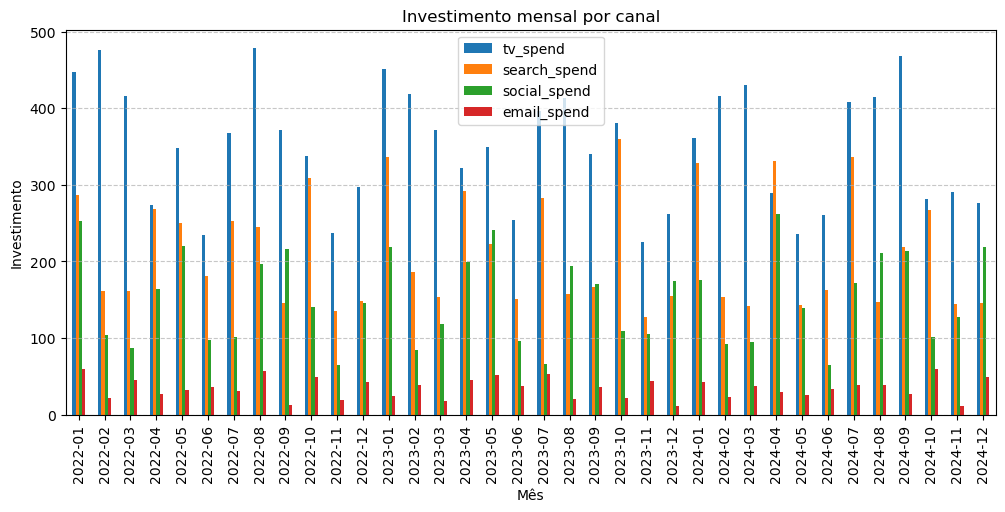

In [28]:
channels = ["tv_spend","search_spend","social_spend","email_spend"]

df_month = df.copy()
df_month["month"] = df_month["date"].dt.to_period("M")

df_month = df_month.groupby("month")[channels].sum()

df_month.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Investimento mensal por canal")
plt.xlabel("Mês")
plt.ylabel("Investimento")
plt.xticks(rotation=90)

plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## 2) Transformações (adstock + saturação)
Aqui usamos parâmetros **fixos** (didático). Em projetos reais, você estimaria/validaria esses parâmetros.


In [52]:
# Parâmetros iniciais (chute informado)
'''
decay - memória da publicidade (Adstock)
alpha - formato da curva
gamma - ponto de saturação
| canal  | decay | interpretação        |
| ------ | ----- | -------------------- |
| TV     | 0.50  | efeito dura bastante |
| Search | 0.30  | efeito mais curto    |
| Social | 0.35  | efeito médio         |
| Email  | 0.20  | efeito muito curto   |

'''
params = {
    "tv_spend": TransformParams(decay=0.50, alpha=1.3, gamma=170),
    "search_spend": TransformParams(decay=0.30, alpha=1.2, gamma=85),
    "social_spend": TransformParams(decay=0.35, alpha=1.1, gamma=65),
    "email_spend": TransformParams(decay=0.20, alpha=1.0, gamma=16),
}

X, feature_names = build_design_matrix(df, params)
y = df["sales"]
X.head()


,tv_spend_transformed,search_spend_transformed,social_spend_transformed,email_spend_transformed,price_index,promo
0,0.256822,0.401923,0.371061,0.505895,1.003047,0
1,0.395335,0.514195,0.533768,0.529984,0.998895,0
2,0.430604,0.511771,0.555814,0.553576,1.023964,1
3,0.480557,0.475666,0.523037,0.426865,1.029260,0
4,0.552843,0.416644,0.559696,0.294768,0.999190,0


## 3) Treino do modelo (OLS)


In [39]:
model = train_linear_model(X, y)
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sales   R-squared:                       0.532
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     28.23
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           2.27e-22
Time:                        21:26:26   Log-Likelihood:                -699.61
No. Observations:                 156   AIC:                             1413.
Df Residuals:                     149   BIC:                             1435.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                      417.6726    146.240      2.856      0.005     128.701     706.644
tv_spend_transformed       189.2314     24.998      7.570      0.000     139.834     238.629
search_spend_transformed   108.3222     25.142      4.308      0.000      58.641     158.003
social_spend_transformed    61.4735     16.303      3.771      0.000      29.258      93.689
email_spend_transformed     27.2682     12.214      2.233      0.027       3.134      51.403
price_index               -223.8680    151.736     -1.475      0.142    -523.700      75.964
promo                       36.5884      4.960      7.377      0.000      26.788      46.389
==============================================================================
Omnibus:                        6.230   Durbin-Watson:                   0.405
Prob(Omnibus):                  0.044   Jarque-Bera (JB):                3.273
Skew:                          -0.090   Prob(JB):                        0.195
Kurtosis:                       2.314   Cond. No.                         199.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 4) Decomposição de contribuição
Vamos decompor a previsão em contribuições por canal/controle e comparar com as vendas.


In [42]:
contrib = decompose_contributions(model, X)
contrib["date"] = df["date"].values
contrib.head()


,intercept,tv_spend_transformed,search_spend_transformed,social_spend_transformed,email_spend_transformed,price_index,promo,prediction,date
0,417.67259,48.598733,43.537143,22.810395,13.794856,-224.550174,0.000000,321.863543,2022-01-03
1,417.67259,74.809735,55.698711,32.812575,14.451700,-223.620551,0.000000,371.824760,2022-01-10
2,417.67259,81.483895,55.436139,34.167834,15.095031,-229.232825,36.588416,411.211080,2022-01-17
3,417.67259,90.936509,51.525146,32.152913,11.639840,-230.418349,0.000000,373.508648,2022-01-24
4,417.67259,104.615259,45.131830,34.406469,8.037804,-223.686671,0.000000,386.177281,2022-01-31


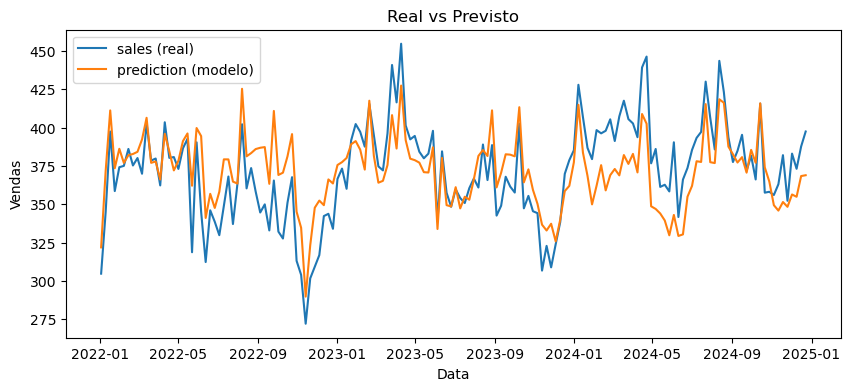

In [44]:
fig = plt.figure(figsize=(10,4))
plt.plot(df["date"], df["sales"], label="sales (real)")
plt.plot(df["date"], contrib["prediction"], label="prediction (modelo)")
plt.title("Real vs Previsto")
plt.xlabel("Data")
plt.ylabel("Vendas")
plt.legend()
plt.show()


### Contribuição total por variável (soma no período)


In [47]:
total = contrib.drop(columns=["prediction","date"]).sum().sort_values(ascending=False)
total


intercept                   65156.924028
tv_spend_transformed        13999.608736
search_spend_transformed     7259.581316
social_spend_transformed     4102.700471
email_spend_transformed      1506.727139
promo                         878.121975
price_index                -34902.747566
dtype: float64

## 5) Recomendação acionável (exemplo)
- Se um canal tem alta contribuição e ainda parece pouco saturado, pode ser candidato para aumento.
- Se um canal contribui pouco e/ou aparenta saturação, pode ser candidato para redução.
